Set directories and parameters

In [1]:
# beta_dir = "example_data/example_beta_files/"
beta_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/beta_files/"
catalog_dir = "/Users/ivandevert/projects/ridgecrest2019_prev/res/event_catalog.txt"
delsig_catalog_dir = "/Users/ivandevert/projects/spectral_falloff_ratio/data/other/shearer_2022_full_delsig_local_ecs.csv"

components = ['z']
units = ['h']
# units = ['n']

stn_req = 2
nrecords_min = 1
dist_bin_width = 10

dist_max = 1000

xsec_dmax = 1500

load_df = True
# load_df = False

# beta_shift_range = [1.4, 1.6]
beta_shift_range = [1.9, 2.1]


In [2]:
# %matplotlib ipympl


import numpy as np
import scipy
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
import struct
import math
import time
import sys

sys.path.append('..')

import stressdrop_file_IO as sdio
import seismo_functions as sf
import mapping_tools as mt
import importlib
importlib.reload(sdio)
import obspy

from scipy import sparse
import utm
import copy 

import ipywidgets as widgets
from ipywidgets import interactive

from shapely.geometry import Point, MultiPoint
from shapely.geometry.polygon import Polygon

from lib.beta_functions import read_beta_files, read_betatxt_files


In [3]:
components = [el.lower() for el in components]

Define some functions

In [4]:
## DataFrame functions
def filter_stn(row, stn_req, dependents):
    # print(row)
    keep_bool = np.array(row['stn'])>=stn_req

    for el in dependents:
        row[el] = row[el][keep_bool]
    return row

def avg_dist(row):
    return np.mean(row['deldist'])


# def get_slope(row):
#     if len(row['qmag']) > 1:
#         m = fit_line_p_norm(np.array(row['qmag']), np.log10(row['beta']), 1)
#         return m[0], m[1]
#     else:
#         return np.nan, np.nan

def get_slope(row, edges):
    if len(row['qmag']) > 1:
        Xavg, Yavg = get_bins_and_averages(row['qmag'], np.log10(row['beta']), edges=edges, method='median')
        if len(Xavg) > 1:
            m = fit_line_p_norm(Xavg, Yavg, 1)
            return m[0], m[1]
        else:
            return np.nan, np.nan
    else:
        return np.nan, np.nan

## end DataFrame functions



def get_colormap(d, cmap='coolwarm_r', method='percentile', **kwargs):

    d = d.astype(float)
    n = len(d)
    
    if method=='percentile':
        assert 'percentiles' in kwargs.keys(), "percentiles must be in kwargs"

        pct = kwargs['percentiles']

        d_sort = np.sort(d)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(d_sort[int(pct[0]*n)], d_sort[int(pct[1]*n)], 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    if method=='mediancenter':

        center = np.median(d)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        d_sort = np.sort(d)

        center_dists = np.array(center - d_sort[int(pct[0]*n)], 
                                d_sort[int(pct[1]*n)] - center)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.linspace(center-dist, center+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    if method=='logmediancenter':
        logd = np.log10(d)
        logcenter = np.median(logd)
        if 'percentiles' in kwargs.keys():
            pct = kwargs['percentiles']
        else:
            pct = [0.05, 0.95]
        
        logd_sort = np.sort(logd)

        center_dists = np.array(logcenter - logd_sort[int(pct[0]*n)], 
                                logd_sort[int(pct[1]*n)] - logcenter)
        dist = np.mean(center_dists)

        cmap = plt.get_cmap(cmap)
        bounds = np.logspace(logcenter-dist, logcenter+dist, 7)
        norm = mpl.colors.BoundaryNorm(bounds, cmap.N, extend='both')

        smap = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

    return cmap, smap, norm



def p_norm(v, p):
    """Return the p-norm of a vector v (see ref. [2])

    Args:
        v (np.ndarray): array to calculate p-norm of
        p (int): p for p-norm

    Returns:
        float: p-norm of v
    """
    return np.power(np.sum(np.power(np.abs(v), p)), 1/p)

def model_p_norm(m, model_function, t, d, p):
    """Intermediate function for calculating the p-norm.

    Args:
        m (array-like): array of model parameters
        model_function (function): callable function
        t (np.ndarray): independent variable
        d (np.ndarray): data array
        p (int): p for p-norm

    Returns:
        float: p-norm of the residual (expected - observed) array
    """
    y = model_function(m, t)
    return p_norm(y - d, p)

def fit_p_norm(x, d, model, m0, p):
    """Find a fit to a model using scipy.optimize.minimize()

    Args:
        x (np.ndarray): independent variable
        d (np.ndarray): observations
        model (function): callable function, with inputs m (model 
            params) and x
        m0 (array-like): starting values for model parameters
        p (int): integer for choosing p-norm (1: L1-norm, 2: L2-norm, 
            etc.)

    Returns:
        np.ndarray: Best-fit model parameters
    """
    from scipy.optimize import minimize
    res = minimize(model_p_norm, m0, args=(model, x, d, p))
    return res.x

def line_model(m, x):
    """Slope-intercept form of a line.

    Args:
        m (array-like): (slope, intercept)
        x (np.ndarray): independent variable

    Returns:
        np.ndarray: y values on line
    """
    return m[0] * x + m[1]

def fit_line_p_norm(x, y, p):
    """Fit a simple line to x, y data using the p-norm.

    Args:
        x (np.ndarray): x values of data
        y (np.ndarray): y values of data
        p (np.ndarray): which norm to use to calculate the line 
            parameters. Least-squares when p==2.

    Returns:
        np.ndarray: (slope, intercept) of best-fit line.
    """
    m0 = np.polyfit(x, y, 1)
    return fit_p_norm(x, y, line_model, m0, p)

def plot_poly(poly, ax, color='k'):
    poly = np.array(poly)
    n = len(poly)
    ax.plot(poly[:,0], poly[:,1], c=color)
    ax.plot([poly[-1, 0], poly[0, 0]], [poly[-1, 1], poly[0, 1]], c=color)

def get_bins_and_averages(x, y, edges, method='mean'):
    """Calculates the average value y in bins along x binned by edges.

    Args:
        x (np.ndarray): variable to separate into bins
        y (np.ndarray): variable to calculate average of
        edges (np.ndarray): points along x to on which to bin
        method (str, optional): 'mean' or 'median'. Defaults to 'mean'.

    Returns:
        midpoints (np.ndarray): linear mean of the edges around the bin
        avg_bin (np.ndarray): average of the y values in the bin. 
    
    Notes:
        - formerly known as 'bin_data_average()'
    """
    ledges = edges[:-1]
    redges = edges[1:]
    midpoints = (ledges + redges)/2
    avg_bin = np.zeros(len(ledges), dtype=float)

    if method=='mean': avg_func = np.mean
    elif method=='median': avg_func = np.median
    for ii in np.arange(len(ledges)):
        bin_bool = np.logical_and(x >= ledges[ii], x < redges[ii])
        data = y[bin_bool]
        data = data[np.logical_not(np.isnan(data))]
        if len(data) > 0:
            avg_bin[ii] = avg_func(data)
        else:
            avg_bin[ii] = np.nan
    
    occupied_bool = np.logical_not(np.isnan(avg_bin))
    midpoints = midpoints[occupied_bool]
    avg_bin = avg_bin[occupied_bool]

    return midpoints, avg_bin



Load earthquake catalogs (for locations) and previous results (for stress drop)

In [5]:
# cat = pd.read_csv(catalog_dir, sep='\\s+')
delsig_cat_names = ["event_id", 'qyr', 'qmon', 'qday', 'qhr', 'qmn', 'qsc', 
                    "qmag", 'qlat', 'qlon', 'qdep', 'ntraces', 'ncal', 'fc', 
                    'misfit', 'delsig', 'mest', 'mw_est', 'm0', 'beta']
delsig_cat = pd.read_csv(delsig_catalog_dir, names=delsig_cat_names)
delsig_cat = delsig_cat[['event_id', 'delsig']]

# initialize distance bin array
dist_bins = np.arange(0, dist_max+1, dist_bin_width)

A =     np.array([4.33E5, 3.974E6])
Ap =    np.array([4.665E5, 3.938E6])

B =     np.array([4.40E5, 3.9343E6])
Bp =    np.array([4.60E5, 3.9543E6])

Load data, index events and stations, and filter out bad results. This is to setup for the inverse problem.

In [6]:
data_dir = 'data/'
data_dir_files = os.listdir(data_dir)

# These are columns that are station-dependent, event-dependent, and 
# both-dependent. pandas pivot_table might be useful here
st_dep = ['stname', 'slat', 'slon', 'selev']
ev_dep = ['event_id', 'qmag', "qlon", "qlat", "qdep"]
dependents = ['beta', 'stn', 'deldist']

if all([el in data_dir_files for el in ['df.pkl', 'df_sta.pkl', 'df_ev.pkl']])\
    and load_df:
    print("Loading pre-computed DataFrames. Change 'load_df' to False to"
        " re-compute.")
    df = pd.read_pickle(data_dir + 'df.pkl')
    df_sta = pd.read_pickle(data_dir + 'df_sta.pkl')
    df_ev = pd.read_pickle(data_dir + 'df_ev.pkl')

    st_dep += ['seasting', 'snorthing', 'stind']
    ev_dep += ['easting', 'northing', 'evind']
    dependents += ['distind']
else:

    print("Computing DataFrames from saved .beta files...")
    # read betatxt files into df_sta DataFrame
    # df_sta = read_betatxt_files(beta_dir)
    df_sta = read_beta_files(beta_dir)
    nstations_initial = len(df_sta)

    # remove undesired components
    inds = []
    for i, el in enumerate(df_sta['stname'].values):
        if el[-1].lower() in components: inds += [i]
    df_sta = df_sta.iloc[inds]
    df_sta.reset_index(drop=True, inplace=True)
    n_remove_components = nstations_initial-len(df_sta)
    print(f"{n_remove_components} channels removed based on components.")

    # remove undesired units
    inds = []
    for i, el in enumerate(df_sta['stname'].values):
        if el[-2].lower() in units: inds += [i]
    df_sta = df_sta.iloc[inds]
    df_sta.reset_index(drop=True, inplace=True)
    print(f"{nstations_initial-len(df_sta)+n_remove_components} channels "
    "removed based on seismogram units.")

    # Compute seastings and snorthings (station locations)
    df_sta['seasting'], df_sta['snorthing'], zn, zl = utm.from_latlon(
        df_sta['slat'].values, 
        df_sta['slon'].values
        )
    st_dep += ['seasting', 'snorthing']
    df_sta.reset_index(drop=True, inplace=True)

    # explode!
    df = df_sta.explode(ev_dep + dependents)
    df['event_id'] = df['event_id'].astype(int)
    df['qmag'] = df['qmag'].astype(float)
    df['qlat'] = df['qlat'].astype(float)
    df['qlon'] = df['qlon'].astype(float)
    df['qdep'] = df['qdep'].astype(float)
    df['beta'] = df['beta'].astype(float)
    df['stn'] = df['stn'].astype(float)
    df['deldist'] = df['deldist'].astype(float)
    nrecords_initial = len(df)

    # get number of initial events
    nevents_initial = len(df['event_id'].unique())
    print(f"{nevents_initial} events, recorded by {nstations_initial} "
        f"stations, resulting in {nrecords_initial} records loaded.")

    # bin values by distance, first removing distant records
    df = df[df['deldist']<=dist_max]
    print(f"{nrecords_initial-len(df)} distant (>{dist_max:.1f} km) records "
        "removed")
    df['distind'] = np.searchsorted(dist_bins, 
                                    df['deldist'].values.astype(float)) - 1
    dependents += ['distind']

    # filter out bad STN records
    df = df[df['stn']>=stn_req]
    df.reset_index(drop=True, inplace=True)
    print(f"{len(df)} records ({len(df)/nrecords_initial*100:.1f}%) passed "
        f"STN ratio requirement of {stn_req:.1f}")

    # make sure each earthquake has enough remaining records
    df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)
    df_ev = df_ev[df_ev['stname'].map(len) >= nrecords_min].reset_index(drop=True)
    print(f"{int(nevents_initial-len(df_ev))} events removed due to not enough"
        f" records (needs >= {nrecords_min})")

    # Compute eastings and northings of events
    df_ev['easting'], df_ev['northing'], zn, zl = utm.from_latlon(
        df_ev['qlat'].values, 
        df_ev['qlon'].values
        )
    ev_dep += ['easting', 'northing']
    df_ev.reset_index(drop=True, inplace=True)

    # add an event index value 'evind' and explode back into df
    df_ev['evind'] = df_ev.index.values.astype(int)
    ev_dep += ['evind']
    df = df_ev.explode(st_dep + dependents)
    df.reset_index(drop=True, inplace=True)

    # group by station to add index
    df_sta = df.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)
    df_sta['stind'] = df_sta.index.values.astype(int)
    st_dep += ['stind']

    # explode!
    df = df_sta.explode(ev_dep + dependents)
    df.reset_index(drop=True, inplace=True)

    # group by event
    df_ev = df.groupby(ev_dep, as_index=False)[st_dep+dependents].agg(list)

    # Save DataFrames
    df.to_pickle(data_dir + "df.pkl")
    print(f"Saved df to {data_dir + 'df.pkl'}")
    df_sta.to_pickle(data_dir + "df_sta.pkl")
    print(f"Saved df_sta to {data_dir + 'df_sta.pkl'}")
    df_ev.to_pickle(data_dir + "df_ev.pkl")
    print(f"Saved df_ev to {data_dir + 'df_ev.pkl'}")



nevents = len(df_ev)
nstations = len(df_sta)
ndata = len(df)

# truncate dist_bins at maximum distance
dist_bins = dist_bins[:np.max(df['distind'])+2]

print("-------------")
print("Final counts:")
print("-------------")
print(f"{nevents} events")
print(f"{nstations} stations")
print(f"{ndata} records")


Loading pre-computed DataFrames. Change 'load_df' to False to re-compute.
-------------
Final counts:
-------------
12929 events
80 stations
326834 records


Make some checks

In [7]:
# number of events should equal number of unique evinds
assert len(df_ev['evind'])==len(df['evind'].unique())

# number of stations should equal number of unique stinds
assert len(df_sta['stind'])==len(df['stind'].unique())

# compute widths of each cross section
A_len = np.sqrt(np.sum(np.power(Ap - A, 2)))
B_len = np.sqrt(np.sum(np.power(Bp - B, 2)))
A_ratio = A_len / (A_len + B_len)
B_ratio = B_len / (A_len + B_len)
gridspec_kw = {"width_ratios": [A_ratio, B_ratio]}


# define 2 boxes by corners and their depths
B1 = (
    (4.5366E5, 3.94991E6),
    (4.5935E5, 3.94928E6),
    (4.6312E5, 3.94269E6),
    (4.5693E5, 3.93928E6)
    )
z1 = (0, 4)

B2 = (
    (4.4154E5, 3.96037E6),
    (4.4581E5, 3.96317E6),
    (4.5311E5, 3.95558E6),
    (4.4824E5, 3.95248E6)
    )
z2 = (0, 12)



# check which events are in the boxes
xyz = df_ev[['easting', 'northing', 'qdep']].values
pts = [Point(xyz[i,:2]) for i in range(len(xyz))]

B1poly = Polygon(B1)
B2poly = Polygon(B2)

B1_center = B1poly.centroid.coords.xy[0][0], B1poly.centroid.coords.xy[1][0]
B2_center = B2poly.centroid.coords.xy[0][0], B2poly.centroid.coords.xy[1][0]

in_dep1 = np.logical_and(xyz[:,2]>=z1[0], xyz[:,2]<=z1[1])
in_dep2 = np.logical_and(xyz[:,2]>=z2[0], xyz[:,2]<=z2[1])

df_ev['in_B1'] = np.logical_and(B1poly.contains(pts), in_dep1)
df_ev['in_B2'] = np.logical_and(B2poly.contains(pts), in_dep2)

print(f"{sum(df_ev['in_B1'])} events in box B1")
print(f"{sum(df_ev['in_B2'])} events in box B2")


737 events in box B1
1585 events in box B2


Load Shearer et al. (2022) delsigs and compute averages inside boxes

In [8]:

delsig_df = pd.merge(delsig_cat, df_ev, how='inner', on='event_id')
# delsig_df = delsig_df[delsig_df['qmag'] <= 5.0]

print(f"{len(df_ev)} events in df_ev, {len(delsig_df)} events in delsig_df")

avg_B1_delsig = np.median(delsig_df['delsig'][delsig_df['in_B1']==True])
avg_B2_delsig = np.median(delsig_df['delsig'][delsig_df['in_B2']==True])

print(f"Average delsig in box B1 ({sum(delsig_df['in_B1'])} events): {avg_B1_delsig:.2f} MPa")
print(f"Average delsig in box B2 ({sum(delsig_df['in_B2'])} events): {avg_B2_delsig:.2f} MPa")



12929 events in df_ev, 4895 events in delsig_df
Average delsig in box B1 (347 events): 6.37 MPa
Average delsig in box B2 (651 events): 13.90 MPa


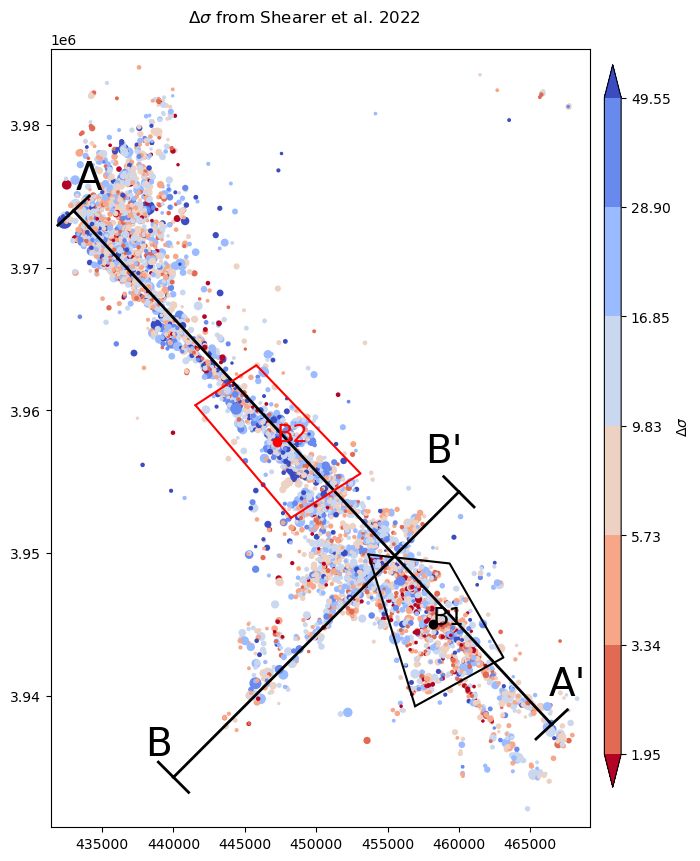

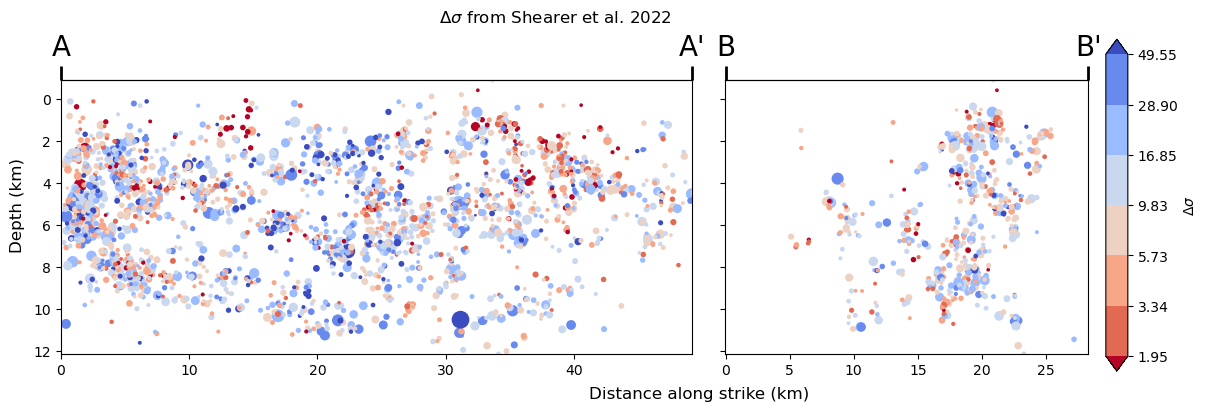

In [9]:

# plot the map-view and cross-sections of stress drop from Shearer et 
# al. (2022) for reference




df_plot = delsig_df
# df_plot = df_ev[np.logical_and(df_ev['qmag']>=1.6, df_ev['qmag']<1.8)]
# df_plot = df_ev[df_ev['qdep']<=1.0]
# df_plot = df_ev

dataname = 'delsig'
datatitle = r"$\Delta\sigma$"

cmap, smap, cnorm = get_colormap(df_plot[dataname].values, method='logmediancenter')

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 8.5),
    layout='constrained')
mapout = mt.plot_map(
    df_plot,
    ax=ax,
    zoom=1.05,
    cname=dataname,
    cnorm=cnorm,
    smap=smap,
    distinguish_clipped=False,
    bgcolor=(1,1,1),

)

mt.plot_xsection_line(A, Ap, ax, labels=["A", "A'"], linewidth=2, 
    exact_tick_length=xsec_dmax)
mt.plot_xsection_line(B, Bp, ax, labels=["B", "B'"], linewidth=2, 
    exact_tick_length=xsec_dmax)

ax.scatter(*B1_center, c='k')
ax.scatter(*B2_center, c='r')

ax.text(*B1_center, "B1", fontsize='xx-large')
ax.text(*B2_center, "B2", fontsize='xx-large', color='r')

cb_ax = fig.add_axes([1.0,.080,.028,.85])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
smap.set_clim([cnorm.vmin, cnorm.vmax])

cbar.ax.set_ylabel(datatitle)
fig.suptitle(datatitle + " from Shearer et al. 2022")

plot_poly(B1, ax, color='k')
plot_poly(B2, ax, color='r')


fig, [ax1, ax2] = plt.subplots(nrows=1, ncols=2, figsize=(11, 4),
    sharey='all', sharex='col', gridspec_kw=gridspec_kw, layout='constrained')


importlib.reload(mt)
xsecoutA = mt.plot_xsection(
    df_plot, 
    p1 = A, 
    p2 = Ap, 
    max_dist = xsec_dmax,
    ax=ax1, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    )

xsecoutB = mt.plot_xsection(
    df_plot, 
    p1 = B, 
    p2 = Bp, 
    max_dist = xsec_dmax,
    ax=ax2, 
    zname='qdep', 
    map_output=mapout,
    xsecunits='line',
    xy_scale=0.001,
    z_scale=1,
    # big_events=EV,
    bgcolor=(1,1,1),
    cname=dataname,
    line_name="B"
    )


fig.supylabel("Depth (km)")
fig.supxlabel("Distance along strike (km)", x=0.63)
fig.suptitle(datatitle + " from Shearer et al. 2022")

# colorbar
cb_ax = fig.add_axes([1.0,.085,.02,.83])
cbar = plt.colorbar(smap, fraction=0.0405, pad=0.02, aspect=35, 
    cax=cb_ax, extend='both')
# smap.set_clim(clim)
# cbar.ax.set_yticks(cticks)
# cbar.ax.set_yticklabels(clabels)
cbar.ax.set_ylabel(datatitle)

# fig.canvas.draw_idle()

plt.show()




In [10]:
# separate DataFrames for events in each box
df_1 = df_ev[df_ev['in_B1']==True].reset_index(drop=True, inplace=False)
df_2 = df_ev[df_ev['in_B2']==True].reset_index(drop=True, inplace=False)

df_1.drop(labels=['in_B1', 'in_B2'], axis='columns')
df_2.drop(labels=['in_B1', 'in_B2'], axis='columns')

df_1 = df_1.explode(st_dep + dependents).reset_index(drop=True, inplace=False)
st_1 = df_1.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

df_2 = df_2.explode(st_dep + dependents).reset_index(drop=True, inplace=False)
st_2 = df_2.groupby(st_dep, as_index=False)[ev_dep+dependents].agg(list)

# df_box_1 = st_1.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)
# df_box_2 = st_2.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)

# df_box_1.to_csv(data_dir + "box1.txt", )
# df_box_2.to_csv(data_dir + "box2.txt", )

# import pandas as pd
# df1 = pd.read_csv('box1.txt')
# df2 = pd.read_csv('box2.txt')

# st_dep = ['stname', 'slat', 'slon', 'selev', 'seasting', 'snorthing', 'stind']
# ev_dep = ['event_id', 'qmag', 'qlon', 'qlat', 'qdep', 'easting', 'northing', 'evind']
# both_dep = ['beta', 'stn', 'deldist', 'distind']
# df1_sta = df1.groupby(st_dep, as_index=False)[ev_dep+both_dep].agg(list)
# df2_sta = df2.groupby(st_dep, as_index=False)[ev_dep+both_dep].agg(list)

Calculate box-station distances

In [44]:
np.log10([el[0] for el in (st_1['beta'] / st_1['shifted_beta']).values])

array([-1.33032486, -1.33604887, -0.65486312, -1.70622294, -0.04033255,
               nan, -0.18754361, -0.33201996, -0.73350039,         nan,
       -1.97320582, -1.6662052 , -1.00914954, -2.07788603, -0.60510254,
       -1.52683998, -0.54023589, -0.26787985, -0.96753831,         nan,
       -0.60911458, -1.41810271, -1.33058979, -1.18800913, -0.99215178,
       -0.79112048, -1.6340865 , -1.06802294, -1.25853418, -0.21585959,
       -0.67182953, -0.61700469, -1.20120163, -1.27513496, -0.29558018,
       -0.39390673, -1.07345553, -0.54516458, -0.75263824, -0.22616314,
       -0.82241207, -0.64221618, -0.52195072, -0.36676205, -0.34554244,
       -1.3824052 ,         nan, -0.91468219, -1.43296053, -0.75486105,
       -0.75363691, -0.72285602, -1.42376851, -0.44464825, -1.13803399,
       -0.94107436, -0.81497012, -1.28432215, -1.10751868, -0.8164909 ,
       -0.38777138, -0.34584785, -0.20908189, -0.2714855 , -0.17128194,
       -0.89559375, -0.90201452])

In [45]:
edges = np.arange(2, 5.1, 0.2)
# edges = np.arange(1, 2.01, 0.2)



def compute_beta_shift(row, m_range):
    qmag = np.array(row['qmag'])
    logbeta = np.log10(row['beta'])
    inds = np.where(np.logical_and(qmag>=m_range[0], qmag<m_range[1]))[0]

    shifted_beta = np.power(10, logbeta - np.median(logbeta[inds]))

    return shifted_beta

st_1['shifted_beta'] = st_1.apply(compute_beta_shift, axis=1, m_range=beta_shift_range)
st_2['shifted_beta'] = st_2.apply(compute_beta_shift, axis=1, m_range=beta_shift_range)

st_1['shift'] = np.log10([el[0] for el in (st_1['beta'] / st_1['shifted_beta']).values])
st_2['shift'] = np.log10([el[0] for el in (st_2['beta'] / st_2['shifted_beta']).values])

# compute the slopes and average distances in each
st_1[['beta_slope', 'beta_y']] = st_1.apply(get_slope, axis=1, result_type='expand', edges=edges)
st_2[['beta_slope', 'beta_y']] = st_2.apply(get_slope, axis=1, result_type='expand', edges=edges)

st_1['avg_dist'] = st_1.apply(avg_dist, axis=1)
st_2['avg_dist'] = st_2.apply(avg_dist, axis=1)

s1_xy = st_1[["seasting", "snorthing"]].values.astype(float)
s2_xy = st_2[["seasting", "snorthing"]].values.astype(float)

st_1['B1_sdist'] = np.sqrt(np.sum(np.power(s1_xy - B1_center, 2), axis=1)) / 1000
st_1['B2_sdist'] = np.sqrt(np.sum(np.power(s1_xy - B2_center, 2), axis=1)) / 1000
st_1['B_deldist'] = st_1['B1_sdist'] - st_1['B2_sdist']

st_2['B1_sdist'] = np.sqrt(np.sum(np.power(s2_xy - B1_center, 2), axis=1)) / 1000
st_2['B2_sdist'] = np.sqrt(np.sum(np.power(s2_xy - B2_center, 2), axis=1)) / 1000
st_2['B_deldist'] = st_2['B1_sdist'] - st_2['B2_sdist']


ST = pd.merge(st_1, st_2, how='inner', on=st_dep+['B1_sdist', 'B2_sdist', 'B_deldist'])
print(f"Box B1 median slope: {np.nanmedian(st_1['beta_slope'].values)}")
print(f"Box B2 median slope: {np.nanmedian(st_2['beta_slope'].values)}")




/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/ivandevert/miniconda3/envs/spectral_falloff/lib/python3.12/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Box B1 median slope: -0.44001060393883157
Box B2 median slope: -0.4636526933608487


Plot the shifted betas

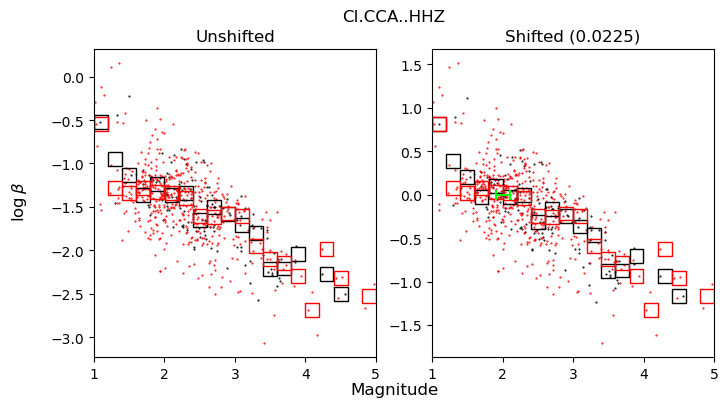

<Figure size 640x480 with 0 Axes>

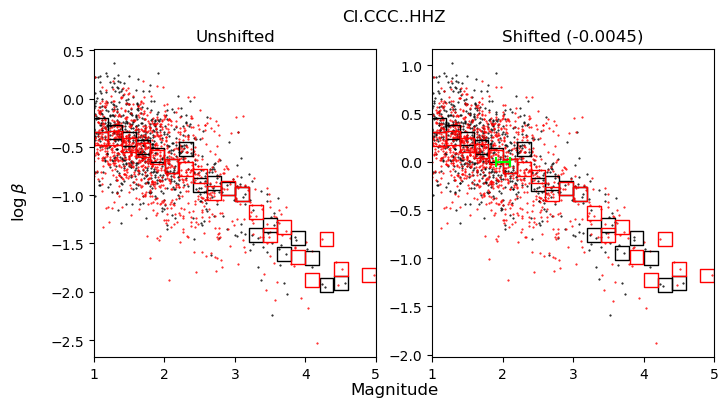

<Figure size 640x480 with 0 Axes>

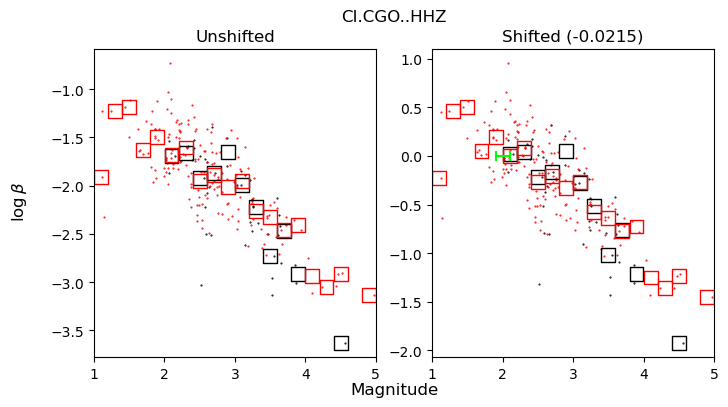

<Figure size 640x480 with 0 Axes>

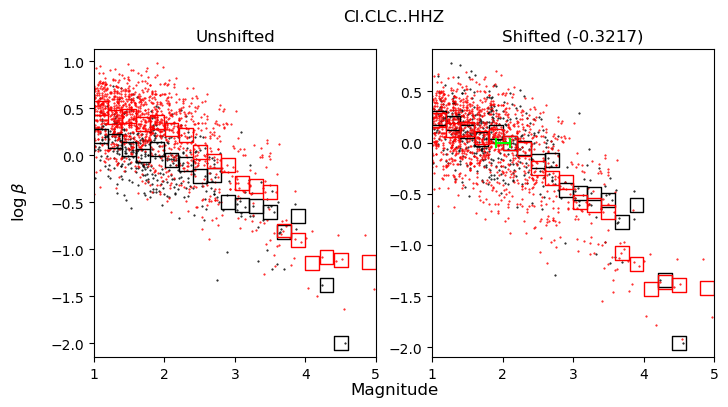

<Figure size 640x480 with 0 Axes>

Box B1 median slope: -0.4405060328691004
Box B2 median slope: -0.4621493101473432
Median difference: 0.008111740838586623


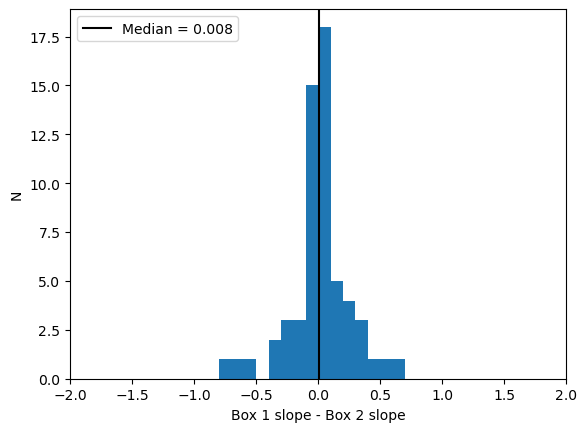

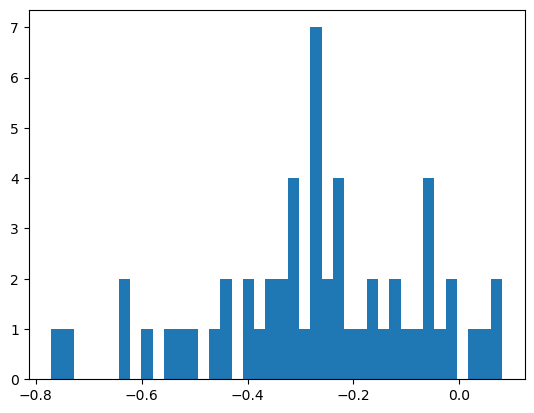

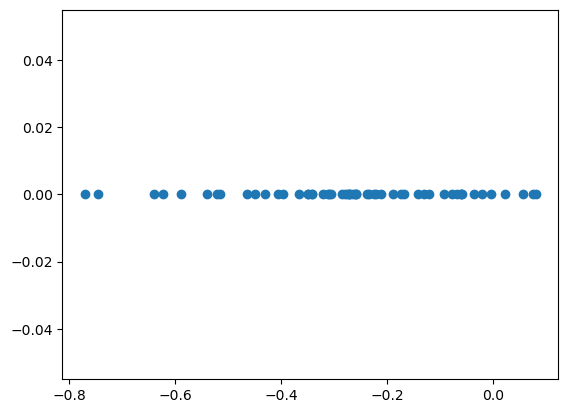

In [28]:
xlim = [1, 5]
X = np.array([0, 5])

edges_all = np.arange(1, 5.1, 0.2)
slope1 = np.empty(len(st_1), dtype=float)
slope2 = np.empty(len(st_1), dtype=float)

B1_deldist = np.empty(len(st_1), dtype=float)
B2_deldist = np.empty(len(st_1), dtype=float)

relative_shift = np.empty(len(st_1), dtype=float)

B1_deldist[:] = np.nan
B2_deldist[:] = np.nan

relative_shift[:] = np.nan

# loop over common stations
slope1[:] = np.nan
slope2[:] = np.nan
for i in range(64):
    stid = st_1['stname'].values[i]
    j = np.where(st_2['stname'].values==stid)[0]

    # if station is common to both DFs, then:
    if len(j)>0:
        j = j[0]
        qmag1 = np.array(st_1.at[i, 'qmag'])
        beta1 = np.array(st_1.at[i, 'beta'])
        shifted_beta1 = np.array(st_1.at[i, 'shifted_beta'])

        qmag2 = np.array(st_2.at[j, 'qmag'])
        beta2 = np.array(st_2.at[j, 'beta'])
        shifted_beta2 = np.array(st_2.at[j, 'shifted_beta'])

        shift1 = np.log10(beta1[0]/shifted_beta1[0])
        shift2 = np.log10(beta2[0]/shifted_beta2[0])

        relative_shift[i] = shift1 - shift2

        if len(qmag1) >10:
            # print(sum(qmag1<=3.0), sum(qmag2<=3.0), st_1['stname'].values[i], st_2['stname'].values[j])
            assert st_1['stname'].values[i]==st_2['stname'].values[j], print('uh oh')

            Xavg1, Yavg1 = get_bins_and_averages(qmag1, np.log10(beta1), edges=edges_all, method='median')
            Xavg2, Yavg2 = get_bins_and_averages(qmag2, np.log10(beta2), edges=edges_all, method='median')

            sXavg1, sYavg1 = get_bins_and_averages(qmag1, np.log10(shifted_beta1), edges=edges_all, method='median')
            sXavg2, sYavg2 = get_bins_and_averages(qmag2, np.log10(shifted_beta2), edges=edges_all, method='median')

            if len(Xavg1)>1 and len(Xavg2)>1:
                # M1 = fit_line_p_norm(Xavg1, Yavg1, 1)
                # M2 = fit_line_p_norm(Xavg2, Yavg2, 1)

                M1 = st_1[['beta_slope', 'beta_y']].values[i,:]
                M2 = st_2[['beta_slope', 'beta_y']].values[j,:]

                slope1[i] = M1[0]
                slope2[i] = M2[0]

                B1_deldist[i] = st_1['B1_sdist'].values[i] - st_2['B1_sdist'].values[j]
                B2_deldist[i] = st_1['B2_sdist'].values[i] - st_2['B2_sdist'].values[j]


                if i < 5:
                    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(8,4))
                    plt.figure()
                    fig.suptitle(st_1['stname'].values[i])
                    ax1.scatter(qmag1, np.log10(beta1), c='k', s=1, marker='.')
                    ax1.scatter(qmag2, np.log10(beta2), c='r', s=1, marker='.')
                    ax1.scatter(Xavg1, Yavg1, edgecolors='k', s=100, marker='s', facecolor='none')
                    ax1.scatter(Xavg2, Yavg2, edgecolors='r', s=100, marker='s', facecolor='none')

                    ax2.scatter(qmag1, np.log10(shifted_beta1), c='k', s=1, marker='.')
                    ax2.scatter(qmag2, np.log10(shifted_beta2), c='r', s=1, marker='.')
                    ax2.scatter(sXavg1, sYavg1, edgecolors='k', s=100, marker='s', facecolor='none')
                    ax2.scatter(sXavg2, sYavg2, edgecolors='r', s=100, marker='s', facecolor='none')

                    # ax2.scatter(sum(beta_shift_range)/2, 0, c='k', marker='x', s=80, zorder=100)
                    ax2.plot(beta_shift_range, [0,0], c='lime', zorder=100)
                    ax2.scatter(beta_shift_range, [0,0], c='lime', marker='|', s=50, zorder=100)
                    
                    ax1.set_xlim(xlim)
                    ax2.set_xlim(xlim)

                    ax1.set_title("Unshifted")
                    ax2.set_title(f"Shifted ({relative_shift[i]:.4f})")
                    # plt.yscale('log')

                    # plt.plot(X, M1[0]*X + M1[1], c='k', label='Box 1 fit')
                    # plt.plot(X, M2[0]*X + M2[1], c='r', label='Box 2 fit')

                    fig.supxlabel("Magnitude")
                    fig.supylabel(r"$\log \beta$")

                    plt.show()



keep_bool = ~np.logical_or(np.isnan(slope1), np.isnan(slope2))
slope1 = slope1[keep_bool]
slope2 = slope2[keep_bool]
B1_deldist = B1_deldist[keep_bool]
B2_deldist = B2_deldist[keep_bool]
relative_shift = relative_shift[keep_bool]
slopediff = slope1 - slope2

print(f"Box B1 median slope: {np.nanmedian(slope1)}")
print(f"Box B2 median slope: {np.nanmedian(slope2)}")
print(f"Median difference: {np.nanmedian(slopediff)}")

bins = np.linspace(-2, 2, 41)
plt.figure()
plt.hist(slopediff, bins=bins)
plt.axvline(np.nanmedian(slopediff), c='k', label=f'Median = {np.nanmedian(slopediff):.3f}')
plt.xlabel('Box 1 slope - Box 2 slope')
plt.ylabel('N')
plt.legend(loc='upper left')
plt.xlim((-2, 2))
plt.show()

plt.figure()
plt.hist(relative_shift, 40)
plt.show()


plt.figure()
plt.scatter(relative_shift, B1_deldist)
plt.show()

# slope2 = np.zeros(len(st_2)) - 99.0
# for i in range(len(st_2)):
#     qmag = np.array(st_2.at[i, 'qmag'])
#     beta = np.array(st_2.at[i, 'beta'])

#     if len(qmag) >1:

#         M = fit_line_p_norm(qmag, np.log10(beta), 1)
#         slope2[i] = M[0]

In [14]:
Yavg2

array([ 4.53900608e-01,  4.25220124e-01,  3.54691877e-01,  3.33534804e-01,
        3.82467004e-01,  3.94873015e-01,  2.64294478e-01,  1.37553223e-01,
        7.95007648e-02, -1.35610017e-02, -1.99127192e-01, -7.16933833e-04,
       -1.13734520e+00, -1.37887598e+00])

In [15]:
# df_box_1 = st_1.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)
# df_box_2 = st_2.explode(ev_dep + dependents).reset_index(drop=True, inplace=False)

# df_box_1.to_csv(data_dir + "box1.txt", )
# df_box_2.to_csv(data_dir + "box2.txt", )

In [16]:
ST['beta_slope_diff'] = ST['beta_slope_x'] - ST['beta_slope_y']
ST = ST.drop(index=np.where(np.isnan(ST['beta_slope_diff'].values))[0])
ST.reset_index(drop=True, inplace=True)

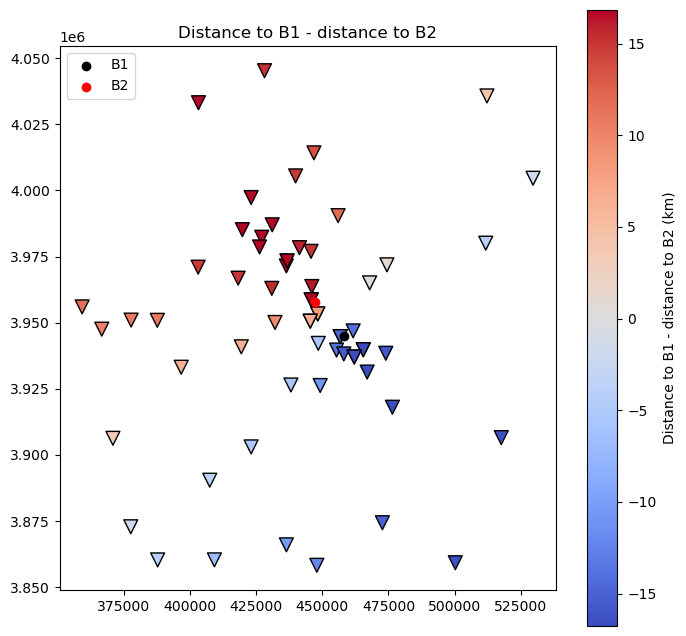

In [17]:

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
sc = ax.scatter(ST['seasting'], ST['snorthing'], edgecolors='k', c=ST['B_deldist'], s=100, marker='v', cmap='coolwarm', norm='linear')
ax.scatter(*B1_center, c='k', label='B1')
ax.scatter(*B2_center, c='r', label='B2')
ax.set_aspect('equal', adjustable='box')
ax.set_title("Distance to B1 - distance to B2")

cbar = plt.colorbar(sc)
cbar.ax.set_ylabel('Distance to B1 - distance to B2 (km)')
plt.legend(loc='upper left')
plt.show()


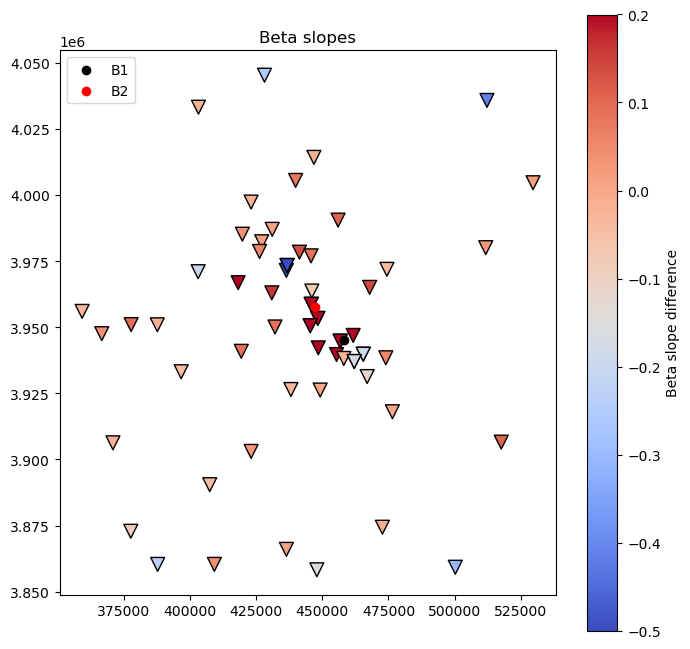

In [18]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
sc = ax.scatter(ST['seasting'], ST['snorthing'], edgecolors='k', c=ST['beta_slope_diff'], s=100, marker='v', cmap='coolwarm', norm='linear', vmin=-0.5, vmax=0.2)
ax.scatter(*B1_center, c='k', label='B1')
ax.scatter(*B2_center, c='r', label='B2')
ax.set_aspect('equal', adjustable='box')
ax.set_title("Beta slopes")

cbar = plt.colorbar(sc)
cbar.ax.set_ylabel('Beta slope difference')
plt.legend(loc='upper left')
plt.show()

In [47]:
ST['shift_x'] - ST['shift_y']

0     0.022503
1    -0.004491
2    -0.021479
3    -0.321705
4          NaN
        ...   
59   -0.271111
60   -0.588734
61   -0.271046
62   -0.049068
63   -0.012153
Length: 64, dtype: float64

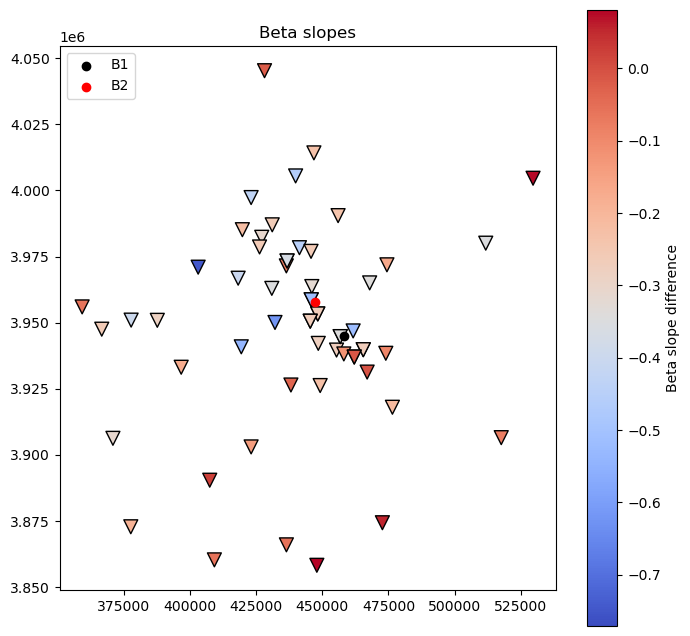

In [52]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8,8))
sc = ax.scatter(ST['seasting'], ST['snorthing'], edgecolors='k', c=ST['shift_x'] - ST['shift_y'], s=100, marker='v', cmap='coolwarm', norm='linear')
ax.scatter(*B1_center, c='k', label='B1')
ax.scatter(*B2_center, c='r', label='B2')
ax.set_aspect('equal', adjustable='box')
ax.set_title("Beta slopes")

cbar = plt.colorbar(sc)
cbar.ax.set_ylabel('Beta slope difference')
plt.legend(loc='upper left')
plt.show()

In [19]:
# def fit_line_emcee(x, y, nwalkers=16):

#     # first, fit the line with a 2 norm
#     M = fit_line_p_norm(qmag, np.log10(beta), 2)


#     # perturb solution
#     ndim = len(M)
#     pos = M + 1e-4 * np.random.randn(nwalkers, ndim)

#     sampler = emcee.EnsembleSampler(
#         nwalkers, ndim, log_probability, args=(x, y, yerr)
#     )

In [20]:
# xlim = [1, 5]
# X = np.array([0, 5])
# slope1 = np.empty(len(st_1), dtype=float)
# slope2 = np.empty(len(st_1), dtype=float)

# B1_deldist = np.empty(len(st_1), dtype=float)
# B2_deldist = np.empty(len(st_1), dtype=float)

# B1_deldist[:] = np.nan
# B2_deldist[:] = np.nan

# # loop over common stations
# slope1[:] = np.nan
# slope2[:] = np.nan
# for i in range(64):
#     stid = st_1['stname'].values[i]
#     j = np.where(st_2['stname'].values==stid)[0]

#     # if station is common to both DFs, then:
#     if len(j)>0:
#         j = j[0]
#         qmag1 = np.array(st_1.at[i, 'qmag'])
#         beta1 = np.array(st_1.at[i, 'beta'])

#         qmag2 = np.array(st_2.at[j, 'qmag'])
#         beta2 = np.array(st_2.at[j, 'beta'])

#         if len(qmag1) >10:
#             # print(sum(qmag1<=3.0), sum(qmag2<=3.0), st_1['stname'].values[i], st_2['stname'].values[j])
#             assert st_1['stname'].values[i]==st_2['stname'].values[j], print('uh oh')

#             Xavg1, Yavg1 = get_bins_and_averages(qmag1, np.log10(beta1), edges=edges, method='median')
#             Xavg2, Yavg2 = get_bins_and_averages(qmag2, np.log10(beta2), edges=edges, method='median')

#             if len(Xavg1)>1 and len(Xavg2)>1:
#                 # M1 = fit_line_p_norm(Xavg1, Yavg1, 1)
#                 # M2 = fit_line_p_norm(Xavg2, Yavg2, 1)

#                 M1 = st_1[['beta_slope', 'beta_y']].values[i,:]
#                 M2 = st_2[['beta_slope', 'beta_y']].values[j,:]

#                 slope1[i] = M1[0]
#                 slope2[i] = M2[0]

#                 B1_deldist[i] = st_1['B1_sdist'].values[i] - st_2['B1_sdist'].values[j]
#                 B2_deldist[i] = st_1['B2_sdist'].values[i] - st_2['B2_sdist'].values[j]


#                 if i < 10:
#                     plt.figure()
#                     plt.title(st_1['stname'].values[i])
#                     plt.scatter(qmag1, np.log10(beta1), c='k', s=1, marker='.')
#                     plt.scatter(qmag2, np.log10(beta2), c='r', s=1, marker='.')

#                     plt.scatter(Xavg1, Yavg1, edgecolors='k', s=100, marker='s', facecolor='none')
#                     plt.scatter(Xavg2, Yavg2, edgecolors='r', s=100, marker='s', facecolor='none')
                    
#                     plt.xlim(xlim)
#                     # plt.yscale('log')

#                     plt.plot(X, M1[0]*X + M1[1], c='k', label='Box 1 fit')
#                     plt.plot(X, M2[0]*X + M2[1], c='r', label='Box 2 fit')

#                     plt.xlabel("Magnitude")
#                     plt.ylabel(r"$\log \beta$")
#                     plt.legend(loc='upper right')

#                     plt.show()



# keep_bool = ~np.logical_or(np.isnan(slope1), np.isnan(slope2))
# slope1 = slope1[keep_bool]
# slope2 = slope2[keep_bool]
# B1_deldist = B1_deldist[keep_bool]
# B2_deldist = B2_deldist[keep_bool]
# slopediff = slope1 - slope2

# print(f"Box B1 median slope: {np.nanmedian(slope1)}")
# print(f"Box B2 median slope: {np.nanmedian(slope2)}")
# print(f"Median difference: {np.nanmedian(slopediff)}")

# bins = np.linspace(-2, 2, 41)
# plt.figure()
# plt.hist(slopediff, bins=bins)
# plt.axvline(np.nanmedian(slopediff), c='k', label=f'Median = {np.nanmedian(slopediff):.3f}')
# plt.xlabel('Box 1 slope - Box 2 slope')
# plt.ylabel('N')
# plt.legend(loc='upper left')
# plt.xlim((-2, 2))
# plt.show()

# plt.figure()
# plt.scatter(B1_deldist, slopediff, c='k')
# plt.scatter(B2_deldist, slopediff, c='r')
# plt.show()


# # slope2 = np.zeros(len(st_2)) - 99.0
# # for i in range(len(st_2)):
# #     qmag = np.array(st_2.at[i, 'qmag'])
# #     beta = np.array(st_2.at[i, 'beta'])

# #     if len(qmag) >1:

# #         M = fit_line_p_norm(qmag, np.log10(beta), 1)
# #         slope2[i] = M[0]

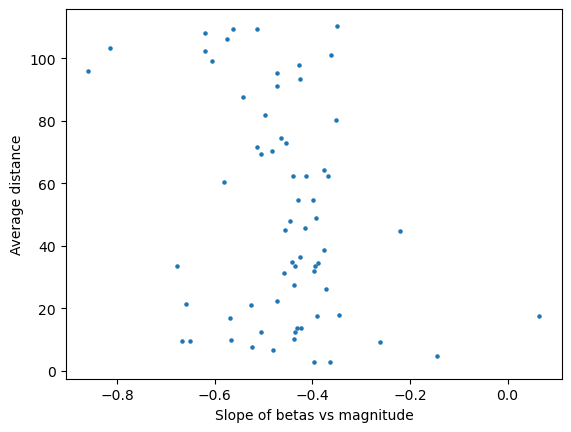

In [21]:
plt.figure()
plt.scatter(np.array(st_1['beta_slope']), np.array(st_1['avg_dist']), s=5)
plt.xlabel("Slope of betas vs magnitude")
plt.ylabel('Average distance')
plt.show()

-0.44001060393883157
-0.4636526933608487


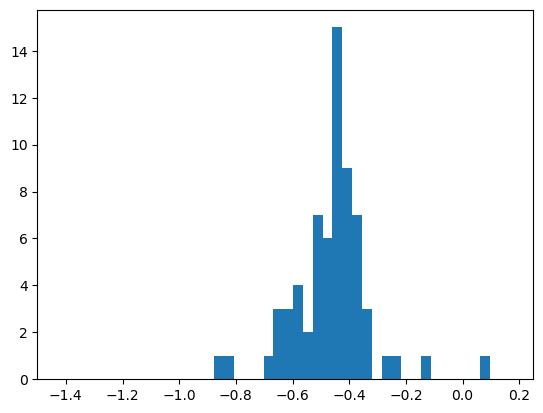

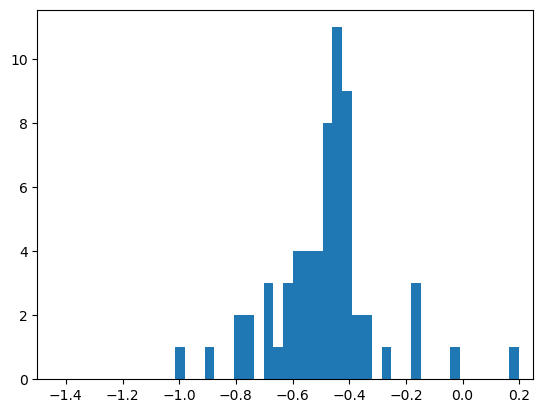

In [22]:
bins = np.linspace(-1.5, 0.2, 50)

print(np.nanmedian(st_1['beta_slope']))
print(np.nanmedian(st_2['beta_slope']))

plt.hist(st_1['beta_slope'], bins=bins)
plt.xlim((-1.5, 0.25))
plt.show()
plt.hist(st_2['beta_slope'], bins=bins)
plt.xlim((-1.5, 0.25))
plt.show()

44.95593846798692
32.76849811939509


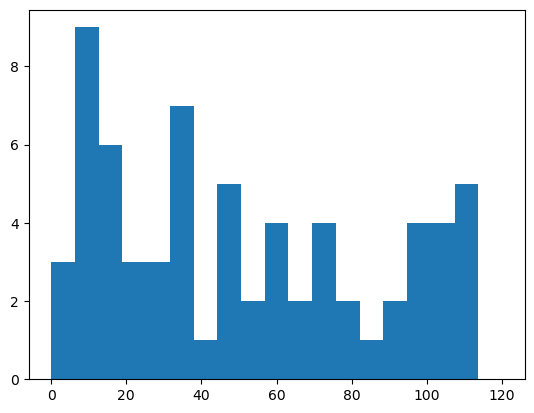

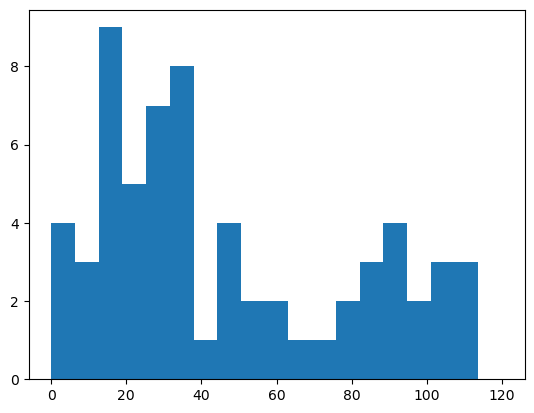

In [23]:
bins = np.linspace(0, 120, 20)

print(np.median(st_1['avg_dist']))
print(np.median(st_2['avg_dist']))

plt.hist(st_1['avg_dist'], bins=bins)
# plt.xlim((-1.5, 0.25))
plt.show()
plt.hist(st_2['avg_dist'], bins=bins)
# plt.xlim((-1.5, 0.25))
plt.show()

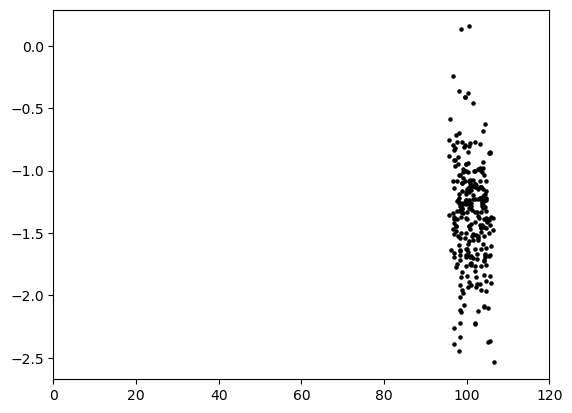

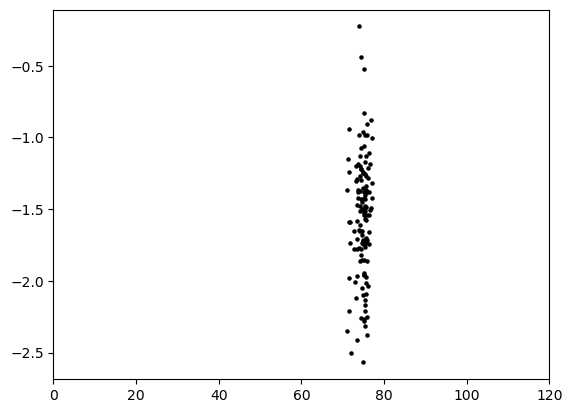

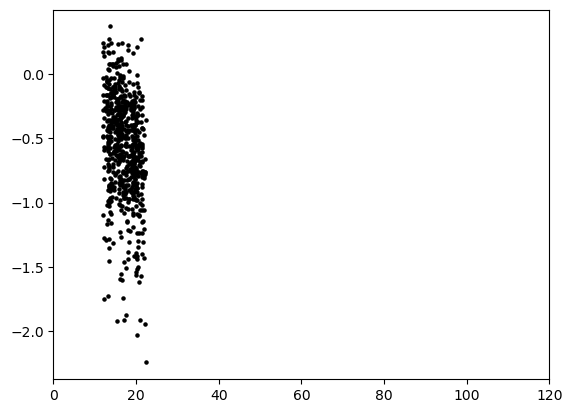

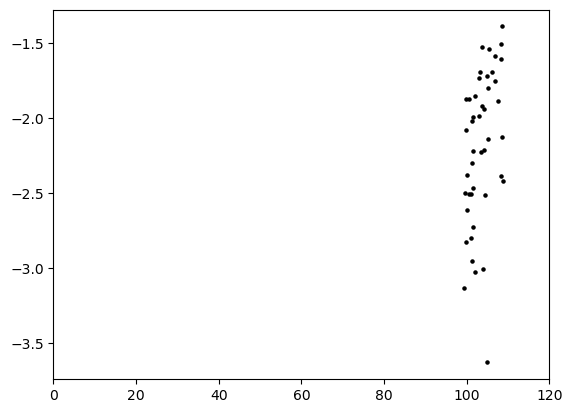

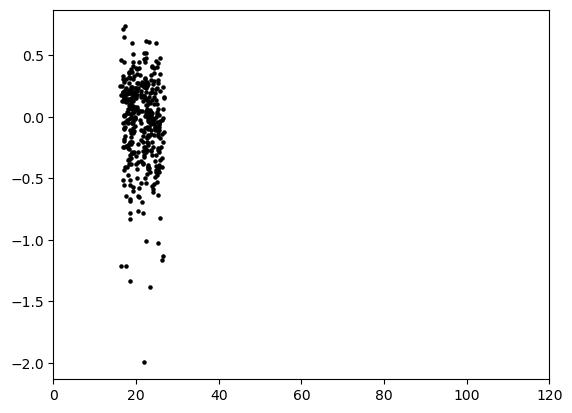

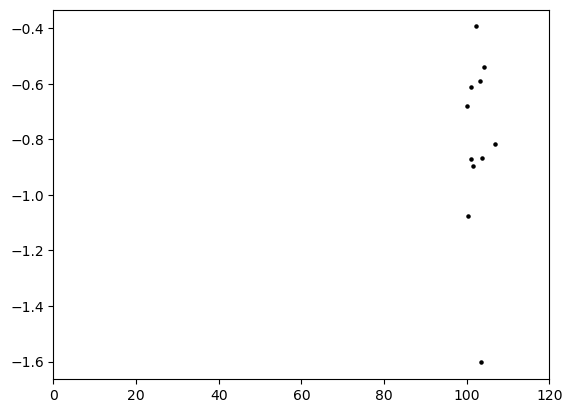

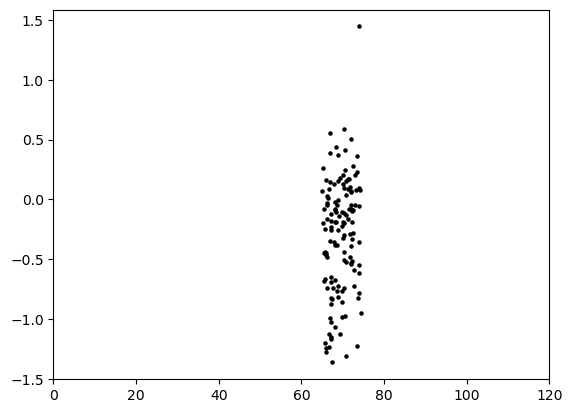

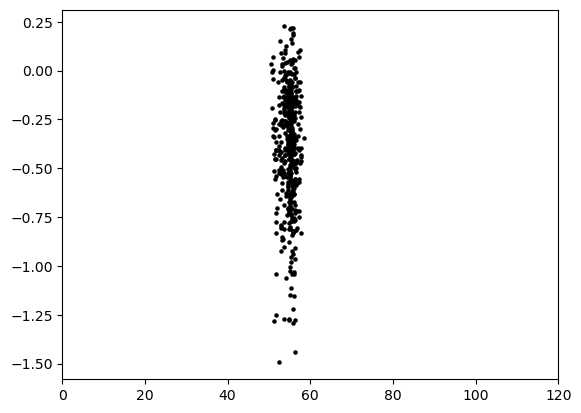

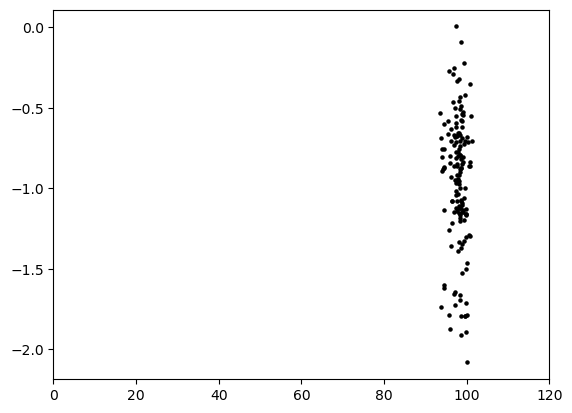

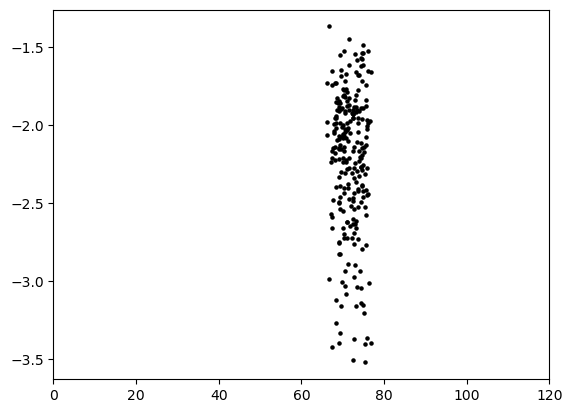

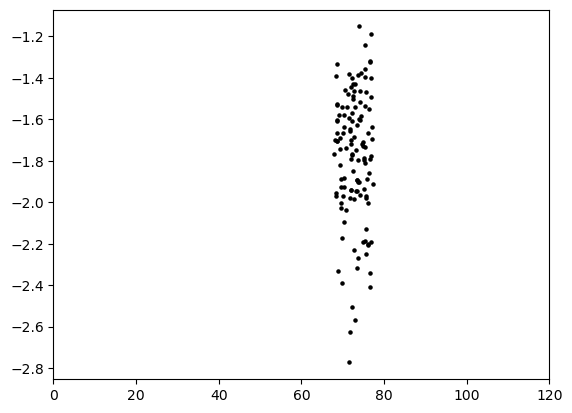

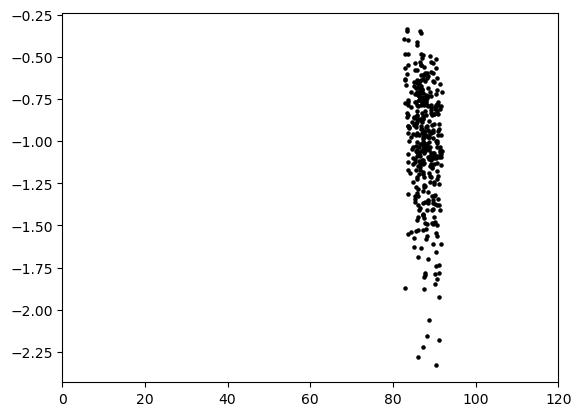

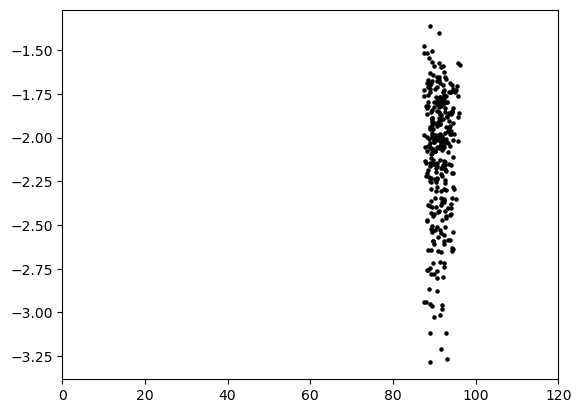

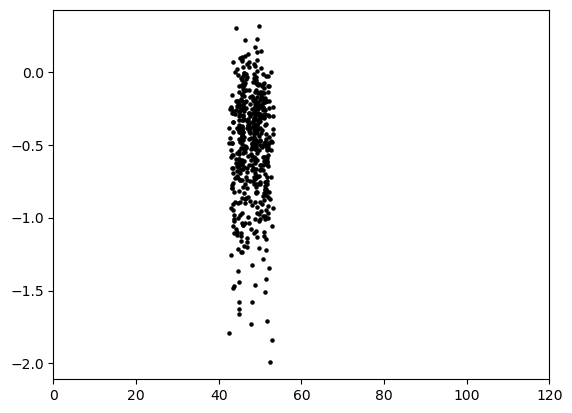

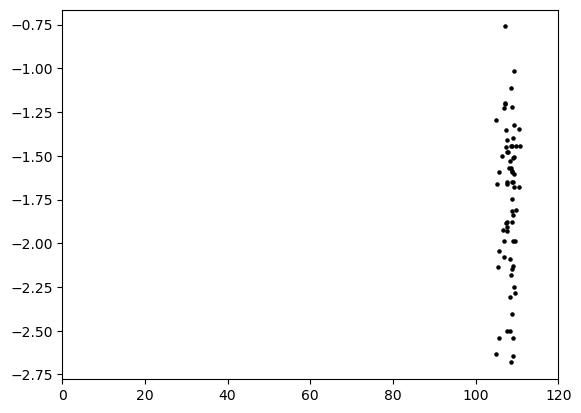

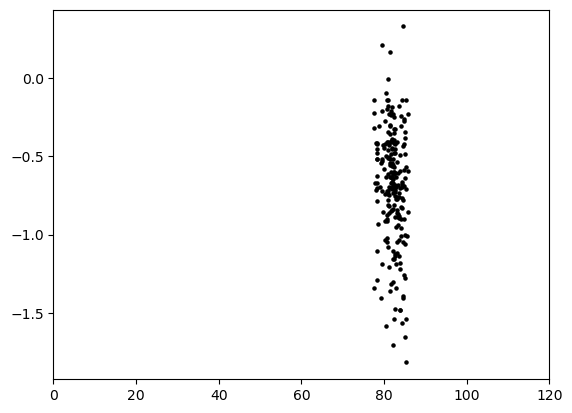

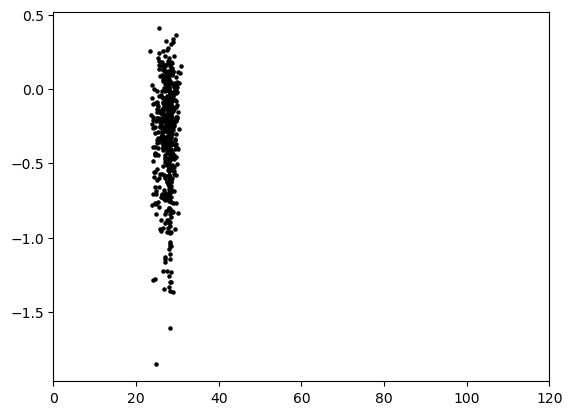

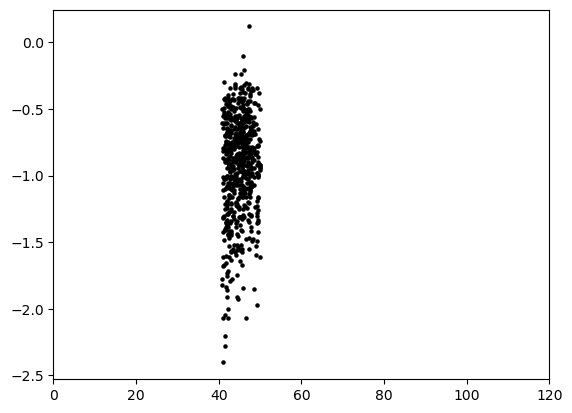

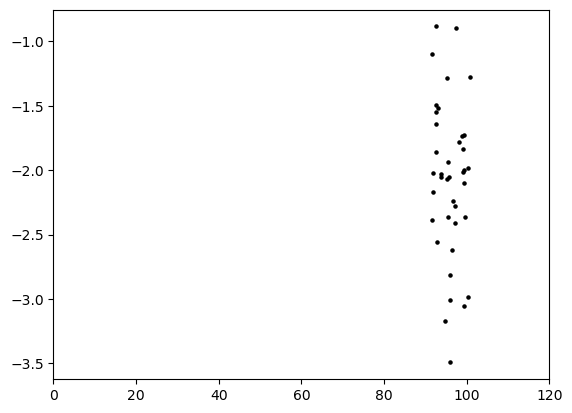

In [24]:
xlim = (0, 120)
for i in range(20):
    dist = np.array(st_1.at[i, 'deldist'])
    beta = np.array(st_1.at[i, 'beta'])

    if len(dist) >10:

        # M = fit_line_p_norm(dist, np.log10(beta), 1)
        # slope1[i] = M[0]
        plt.figure()
        plt.scatter(dist, np.log10(beta), c='k', s=5)
        plt.xlim(xlim)
        # plt.yscale('log')

        # plt.plot(X, M[0]*X + M[1], c='r')

        plt.show()

### emcee testing

Maximum likelihood estimates:
m = -1.003
b = 4.528
f = 0.454


NameError: name 'x0' is not defined

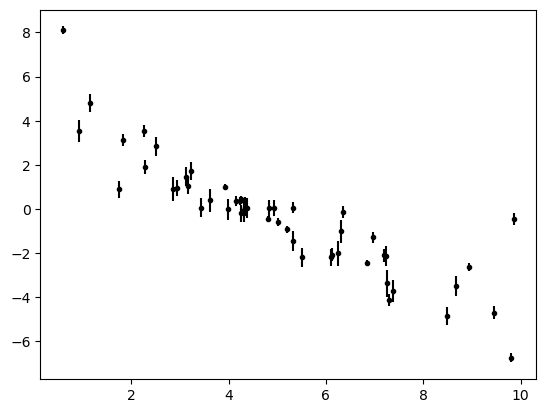

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import emcee
import emcee
import corner 
import tqdm



def log_likelihood(theta, x, y, yerr):
    m, b, log_f = theta
    model = m * x + b
    sigma2 = yerr**2 + model**2 * np.exp(2 * log_f)
    return -0.5 * np.sum((y - model) ** 2 / sigma2 + np.log(sigma2))

def log_prior(theta):
    m, b, log_f = theta
    if -5.0 < m < 0.5 and 0.0 < b < 10.0 and -10.0 < log_f < 1.0:
        return 0.0
    return -np.inf

def log_probability(theta, x, y, yerr):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, yerr)

np.random.seed(123)

# Choose the "true" parameters.
m_true = -0.9594
b_true = 4.294
f_true = 0.534

# Generate some synthetic data from the model.
N = 50
x = np.sort(10 * np.random.rand(N))
yerr = 0.1 + 0.5 * np.random.rand(N)
y = m_true * x + b_true
y += np.abs(f_true * y) * np.random.randn(N)
y += yerr * np.random.randn(N)

from scipy.optimize import minimize

np.random.seed(42)
nll = lambda *args: -log_likelihood(*args)
initial = np.array([m_true, b_true, np.log(f_true)]) + 0.1 * np.random.randn(3)
soln = minimize(nll, initial, args=(x, y, yerr))
m_ml, b_ml, log_f_ml = soln.x

print("Maximum likelihood estimates:")
print("m = {0:.3f}".format(m_ml))
print("b = {0:.3f}".format(b_ml))
print("f = {0:.3f}".format(np.exp(log_f_ml)))

plt.errorbar(x, y, yerr=yerr, fmt=".k", capsize=0)
plt.plot(x0, m_true * x0 + b_true, "k", alpha=0.3, lw=3, label="truth")
plt.plot(x0, np.dot(np.vander(x0, 2), w), "--k", label="LS")
plt.plot(x0, np.dot(np.vander(x0, 2), [m_ml, b_ml]), ":k", label="ML")
plt.legend(fontsize=14)
plt.xlim(0, 10)
plt.xlabel("x")
plt.ylabel("y");



pos = soln.x + 1e-4 * np.random.randn(32, 3)
nwalkers, ndim = pos.shape

sampler = emcee.EnsembleSampler(
    nwalkers, ndim, log_probability, args=(x, y, yerr)
)
sampler.run_mcmc(pos, 5000, progress=True);